/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning:

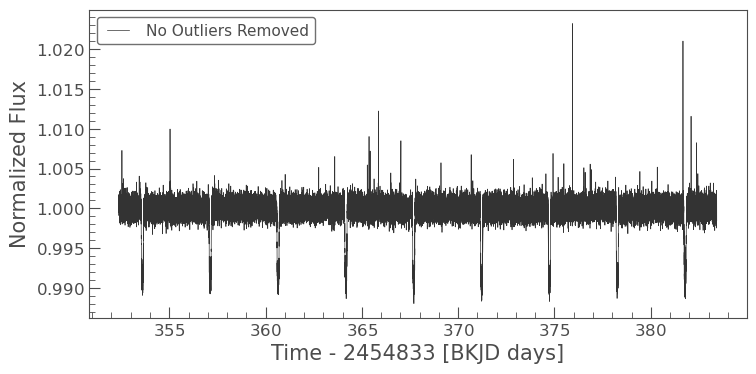

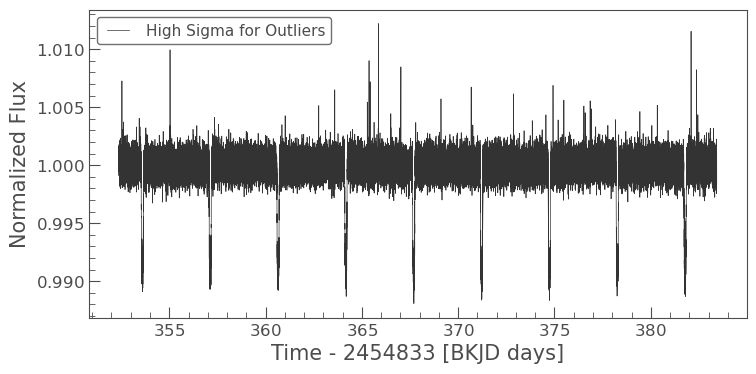

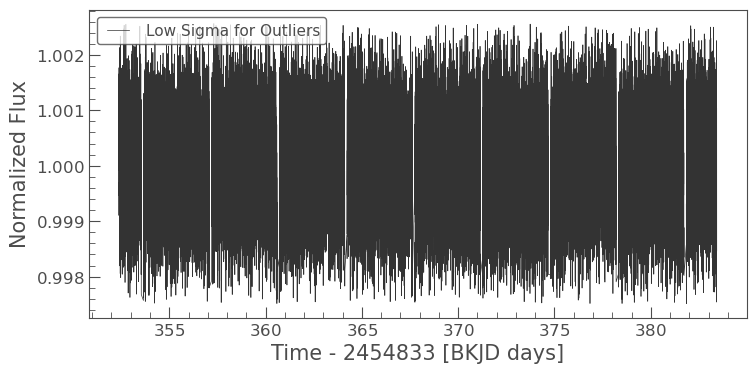

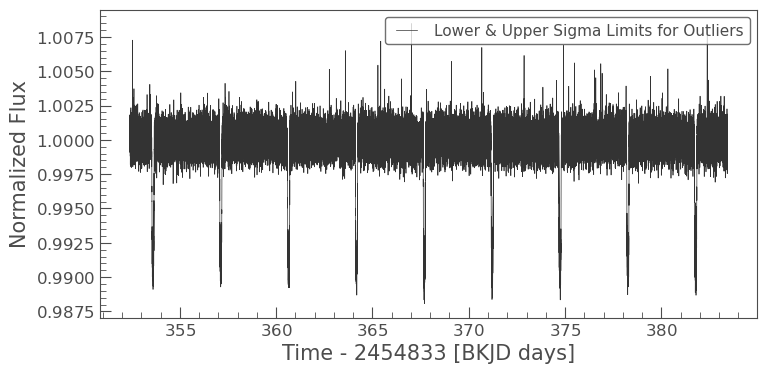

In [8]:
#diff sigma values
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_lightcurve
import warnings

# Download Kepler light curve, clean it, & test different values of sigma
lc_nooutliers = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize()
lc_highsigma = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma=9)
lc_lowsigma = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma=3)
lc_sigmalowerandupper = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma_lower=100, sigma_upper=5)

# Plot lightcurves depending on their various levels of sigma
lc_nooutliers.plot(label="No Outliers Removed")
lc_highsigma.plot(label="High Sigma for Outliers")
lc_lowsigma.plot(label="Low Sigma for Outliers")
lc_sigmalowerandupper.plot(label="Lower & Upper Sigma Limits for Outliers")

import warnings
warnings.filterwarnings("ignore")







/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
The requested periodogram is not evenly sampled in frequency.
Method has been changed from 'fast' to 'slow' to allow for this.


Lomb-Scargle period: 1.7600 d days
BLS period: 3.5200 d days


<Axes: title={'center': 'BLS Periodogram'}, xlabel='Period (days)', ylabel='Power'>

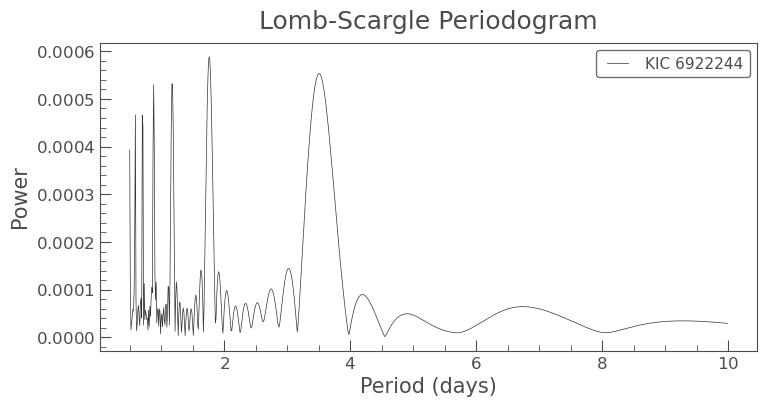

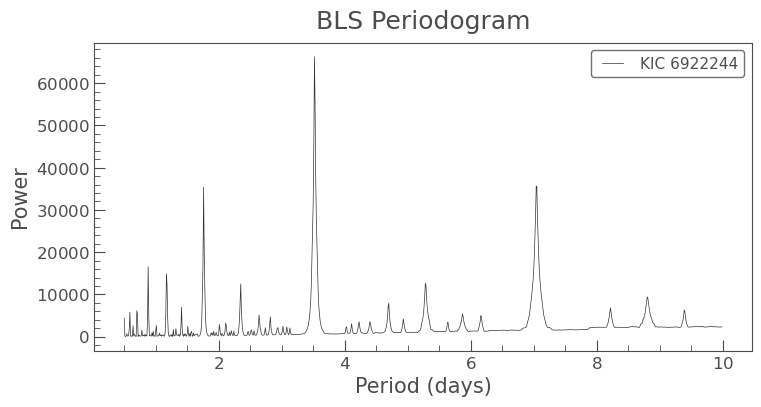

In [2]:
#bls vrs lomgscargle
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_lightcurve

# Download Kepler light curve & clean it up
lc = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma=9)

#Create periodograms using both methods
pd_lombscargle = lc.to_periodogram(method="Lombscargle", period=np.arange(0.5, 10, 0.01))
pd_bls = lc.to_periodogram(method="bls", period=np.arange(0.5, 10, 0.01))

#Creates a variable to represent the best orbital period tied to the highest peak (maxium power) from each of the periodograms
period_bls = pd_bls.period_at_max_power
period_lombscargle = pd_lombscargle.period_at_max_power

#Print resulting orbital period for both methods (Lomb-Scargle + BLS)
print(f"Lomb-Scargle period: {period_lombscargle:.4f} days")
print(f"BLS period: {period_bls:.4f} days")

#Plot different periodograms (Lomb-Scargle + BLS)) 
pd_lombscargle.plot(title="Lomb-Scargle Periodogram", xlabel="Period (days)", ylabel="Power")
pd_bls.plot(title="BLS Periodogram", xlabel="Period (days)", ylabel="Power")


/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


period_bls_at_max power = 3.5200000000000022 d
epoch_time = 353.6118820626667


Text(0.5, 1.0, 'Kepler-8b: window_length = 401')

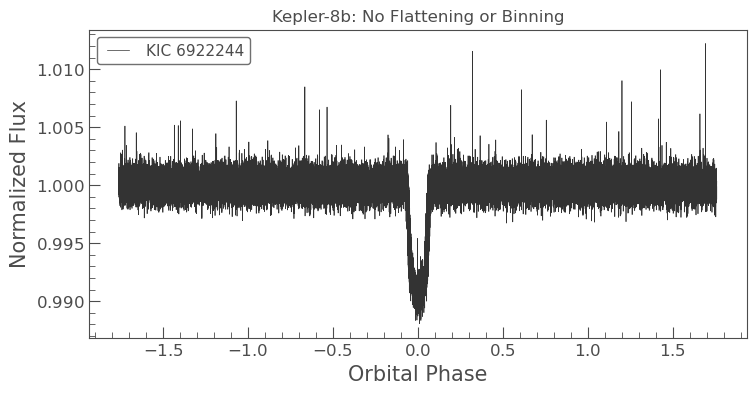

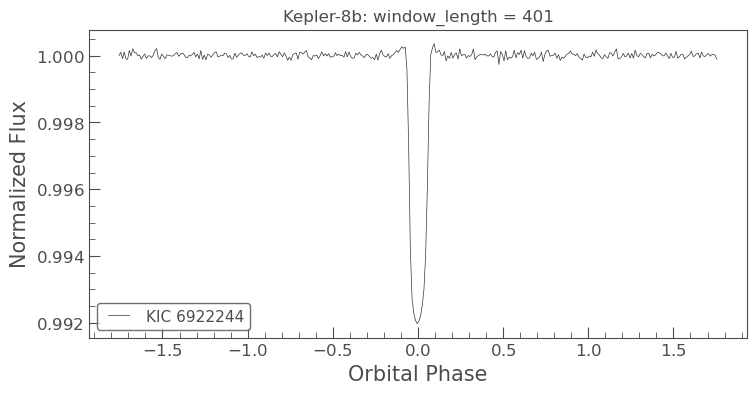

In [3]:
#clean vrs unclean LC
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_lightcurve


# Download Kepler light curve & clean it up
lc = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma=9)

pd_bls = lc.to_periodogram(method="bls", period=np.arange(0.5, 10, 0.01))
#Creates a variable to represent the best orbital period tied to the highest peak (maxium power) from the periodogram
period_bls = pd_bls.period_at_max_power
#Creates a variable that extracts the reference time of the first transit corresponding to the highest peak from the periodogram, pinpointing exactly when an exoplanet cross in front of its star
t0_bls = pd_bls.transit_time_at_max_power

print(f"period_bls_at_max power = {period_bls}")
print(f"epoch_time = {t0_bls}")

#Fold the lightcurve (only) & centers the transit at phase 0
lc_uncleanfold = lc.fold(period=period_bls, epoch_time=t0_bls)

#Plot Light Curve (only has been folded) & set x,y, & title labels
ax_unclean = lc_uncleanfold.plot()

ax_unclean.set_xlabel("Orbital Phase")
ax_unclean.set_ylabel("Normalized Flux")
ax_unclean.set_title("Kepler-8b: No Flattening or Binning")

# --- Flattened + Binned LC

#Flatten light curve with window_length = 401
lc_flattend = lc.flatten(window_length=401)

#Fold lightcurve based on orbital period for KIC 6922244
lc_folded = lc_flattend.fold(period=period_bls, epoch_time=t0_bls)

#Bin the lightcurve
lc_clean = lc_folded.bin(time_bin_size=0.01)

#Plot Light Curve (has been folded, flattened, & binned), and set x,y, & title labels)
ax_clean = lc_clean.plot()

ax_clean.set_xlabel("Orbital Phase")
ax_clean.set_ylabel("Normalized Flux")
ax_clean.set_title("Kepler-8b: window_length = 401")


/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


BLS period: 3.5200000000000022 d
Transit time: 353.6118820626667


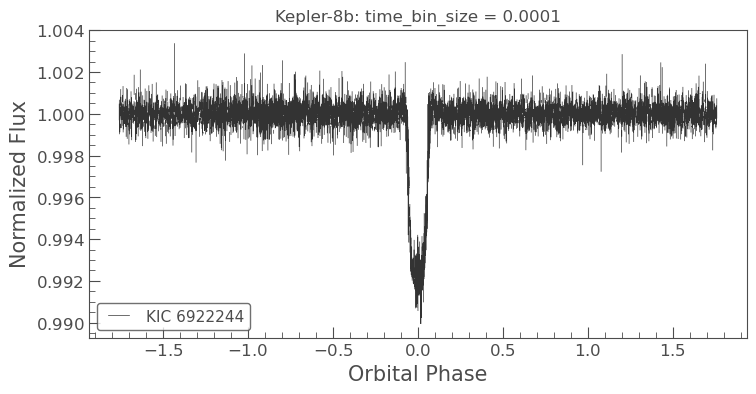

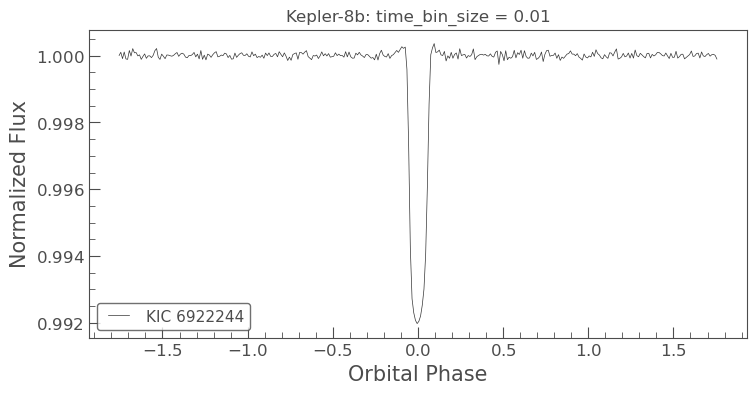

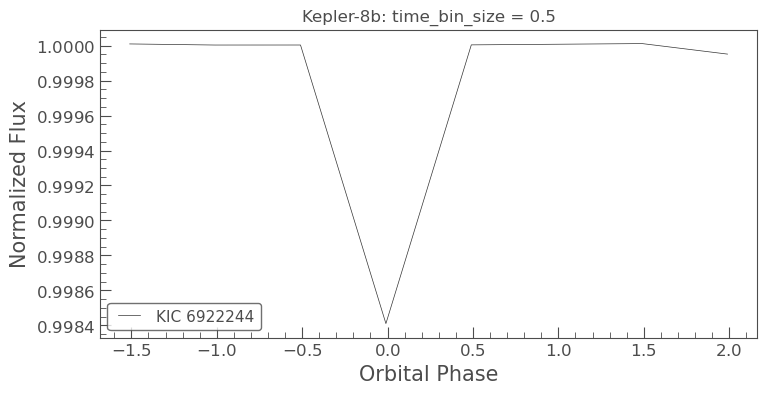

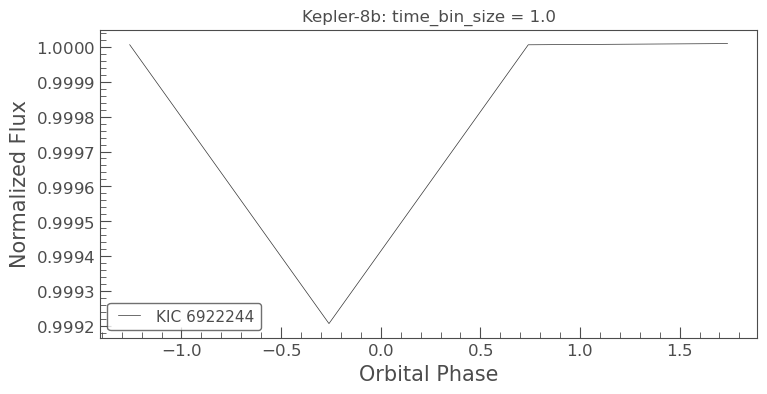

In [4]:
#time_bin_sizes
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_lightcurve


# Download Kepler light curve & clean it up
lc = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma=9)

#Create a periodogram (bls)
pd_bls = lc.to_periodogram(method="bls", period=np.arange(0.5, 10, 0.01))
#Creates a variable that extracts the reference time of the first transit corresponding to the highest peak from the periodogram, pinpointing exactly when an exoplanet cross in front of its star
t0_bls = pd_bls.transit_time_at_max_power


print("BLS period:", period_bls)
print("Transit time:", t0_bls)

# Compares different flattening windows
time_bin_sizes = [0.0001, 0.01, 0.5, 1.0]

for time_bin in time_bin_sizes:

    # Flatten the LC depending on the different window lengths
    lc_flat = lc.flatten(window_length=401)

    # Fold LC using BOTH the period and transit time - centers the transit at phase 0
    lc_folded = lc_flat.fold(period=period_bls, epoch_time=t0_bls)
    
    #Bin the folded light curve
    lc_binned = lc_folded.bin(time_bin_size=time_bin)
    
    #Plote the folded + binned LC: 
    ax = lc_binned.plot()
    
    ax.set_xlabel("Orbital Phase")
    ax.set_ylabel("Normalized Flux")
    ax.set_title(f"Kepler-8b: time_bin_size = {time_bin}")
    
    # Zoom in on the transit
    #?
    
    

/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


BLS period: 3.5200000000000022 d
Transit time: 353.6118820626667
window = 101: F_in = 0.99415, F_out = 1.00000, depth = 0.585%,
window = 201: F_in = 0.99225, F_out = 1.00000, depth = 0.775%,
window = 401: F_in = 0.99182, F_out = 1.00001, depth = 0.819%,
window = 801: F_in = 0.99142, F_out = 1.00001, depth = 0.860%,


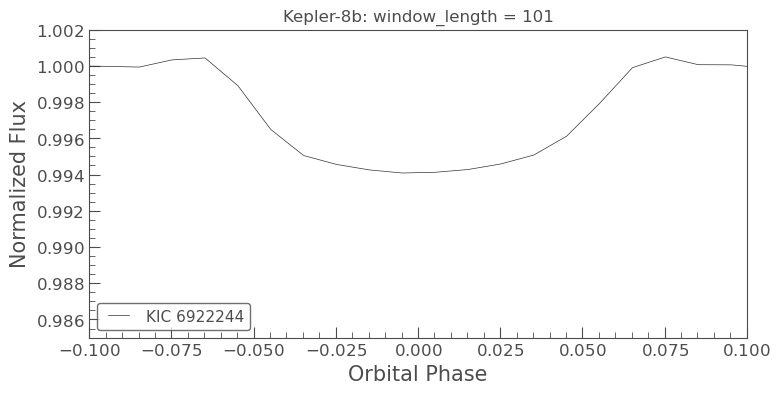

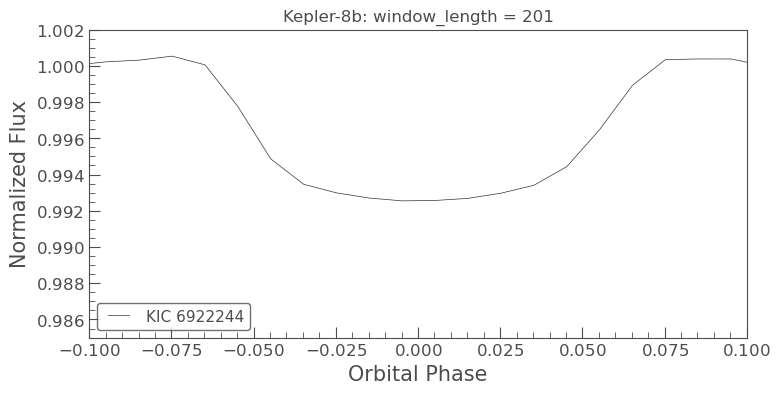

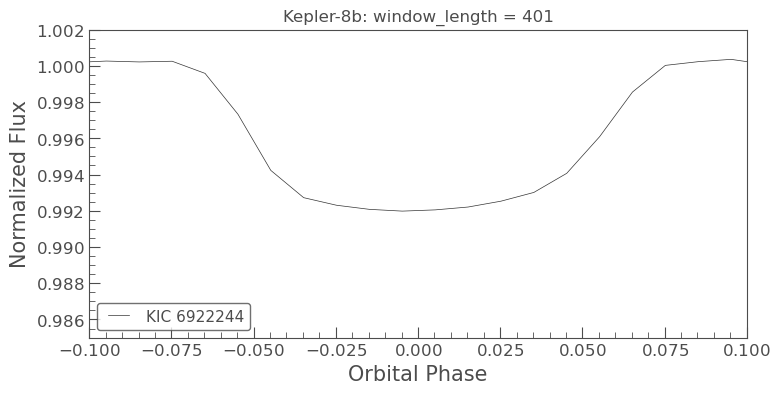

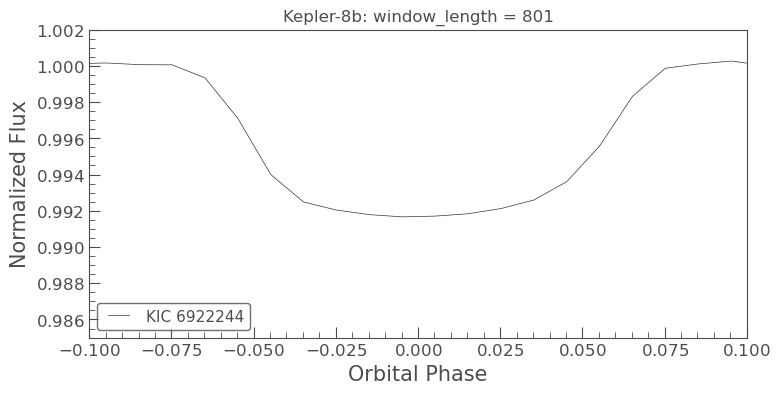

In [5]:
#window_lengths
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk


# Download Kepler light curve & clean it up
lc = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma=9)

#Create periodogram (BLS)
pd_bls = lc.to_periodogram(method="bls",period=np.arange(0.5, 10, 0.01))

#Creates a variable to represent the best orbital period tied to the highest peak (maxium power) from the periodogram
period_bls = pd_bls.period_at_max_power
#Creates a variable that extracts the reference time of the first transit corresponding to the highest peak from the periodogram, pinpointing exactly when an exoplanet cross in front of its star 
t0_bls = pd_bls.transit_time_at_max_power


print("BLS period:", period_bls)
print("Transit time:", t0_bls)

window_lengths = [101, 201, 401, 801]

# Compares different flattening windows
for window in window_lengths:

    # Flatten the LC depending on the different window lengths
    lc_flat = lc.flatten(window_length=window)

    # Fold LC using BOTH the period and transit time - centers transit at 0
    lc_folded = lc_flat.fold(period=period_bls, epoch_time=t0_bls)
    
    #Bin the folded light curve
    lc_binned = lc_folded.bin(time_bin_size=0.01)
    
    #Plote the folded + binned LC: 
    ax = lc_binned.plot()
    
    ax.set_xlabel("Orbital Phase")
    ax.set_ylabel("Normalized Flux")
    ax.set_title(f"Kepler-8b: window_length = {window}")
    
    # Zoom in on the transit
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(0.985, 1.002)
    
    '''ax.annotate(
    f"Transit depth = {depth*100:.3f}%",
    xy=(0, F_in),
    xytext=(0.02, F_in - 0.002),
    arrowprops=dict(arrowstyle="->")
    ) '''
    #come back to later ^^
    

    # Measure transit depth to see if there is a difference between window lengths

    # Creates a variable & extracts raw numerical array of orbital phase values from the LC
    phase = lc_folded.phase.value
    # Creates a variable & extracts raw numerical array of the flux (star brightness) from the LC
    flux = lc_folded.flux.value

    # Central part of transit
    in_transit = (phase > -0.02) & (phase < 0.02)
    out_transit = (phase < -0.1) | (phase > 0.1)
    

    # Median flux values -- Median gives represenative value not affected (as much) by nosiy, scattered points
    # Gets flux measurements occuring during the transit
    F_in = np.median(flux[in_transit])
    # Gets flux measurements occuring outside the transit
    F_out = np.median(flux[out_transit])

    # Calculates transit depth
    depth = (F_out - F_in) / F_out
  
    # Values per graph
    print(
        f"window = {window}: "
        f"F_in = {F_in:.5f}, "
        f"F_out = {F_out:.5f}, "
        f"depth = {depth*100:.3f}%," 
    )

/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


BLS period: 3.5200000000000022 d
Transit time: 353.6118820626667


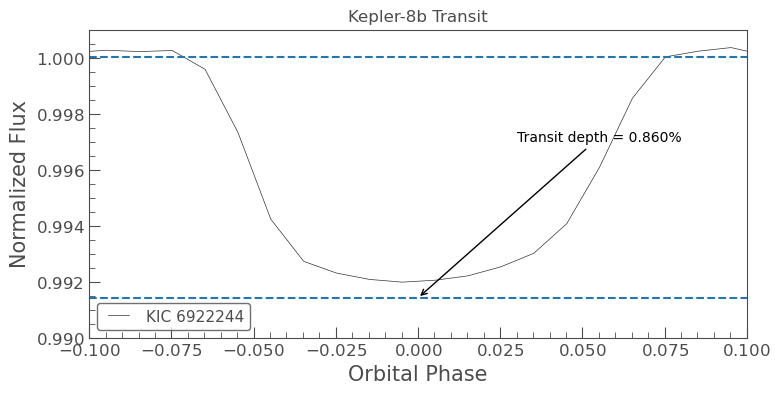

window_length = 401
F_in = 0.99142
F_out = 1.00001
depth = 0.860%
ratio of planet's radius to the star's radius = 0.093
planet's physical radius = 1.439 R_J
percentage difference in planet radius = 1.425%


In [6]:
#window_lengths
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

# Download Kepler light curve & clean it up
lc = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize().remove_outliers(sigma=9)

#Create periodogram (BLS)
pd_bls = lc.to_periodogram(method="bls",period=np.arange(0.5, 10, 0.01))

#Creates a variable to represent the best orbital period tied to the highest peak (maxium power) from the periodogram
period_bls = pd_bls.period_at_max_power
#Creates a variable that extracts the reference time of the first transit corresponding to the highest peak from the periodogram, pinpointing exactly when an exoplanet cross in front of its star 
t0_bls = pd_bls.transit_time_at_max_power


print("BLS period:", period_bls)
print("Transit time:", t0_bls)
    

# Creates a variable & extracts raw numerical array of orbital phase values from the LC
phase = lc_folded.phase.value
# Creates a variable & extracts raw numerical array of the flux (star brightness) from the LC
flux = lc_folded.flux.value

# Central part of transit
in_transit = (phase > -0.02) & (phase < 0.02)
out_transit = (phase < -0.1) | (phase > 0.1)
    
# Median flux values -- Median gives represenative value not affected (as much) by nosiy, scattered points
# Gets flux measurements occuring during the transit
F_in = np.median(flux[in_transit])
# Gets flux measurements occuring outside the transit
F_out = np.median(flux[out_transit])

# Calculates transit depth
depth = (F_out - F_in) / F_out
#Fold LC using BOTH the period and transit time - Centers transit at phase 0
lc_folded = lc_flat.fold(period=period_bls, epoch_time=t0_bls)

# Calculate the ratio of the planet's radius to the star's radius
radius_ratio = np.sqrt(depth)

# Calculate the planet radius
star_radius = 1.56
jupiter_radii = 9.950
planet_radius = radius_ratio*1.56*jupiter_radii
published_planet_radius = 1.419

# Calculate the % difference for planet radius 
planet_radius_difference = abs(planet_radius - published_planet_radius) / published_planet_radius * (100)

# Final Light Curve

# Flatten the LC using window_length value of 401
lc_flat = lc.flatten(window_length=401)

# Fold LC using BOTH the period and transit time - centers transit at 0
lc_folded = lc_flat.fold(period=period_bls, epoch_time=t0_bls)
    
#Bin the folded light curve
lc_binned = lc_folded.bin(time_bin_size=0.01)
    
#Plot the folded + binned LC: 
ax = lc_binned.plot()
    
ax.set_xlabel("Orbital Phase")
ax.set_ylabel("Normalized Flux")
ax.set_title("Kepler-8b: Target KIC 6922244")

#Zoom in on the transit
ax.set_xlim(-0.1, 0.1)
ax.set_ylim(0.990, 1.001)

# Draw line for the flux measurements outside the transit
ax.axhline(
    F_out,
    linestyle="--",
    label=f"F_out = {F_out:.4f}"
)

# Draw line for the flux measurements inside the transit
ax.axhline(
    F_in,
    linestyle="--",
    label=f"F_in = {F_in:.4f}"
)

# Annotate depth onto graph
ax.annotate(
    f"Transit depth = {depth*100:.3f}%",
    xy=(0, F_in),
    xytext=(0.030, 0.997),
    arrowprops=dict(arrowstyle="->")
)

# Titles for graph, x-axis, and y-axis
ax.set_xlabel("Orbital Phase")
ax.set_ylabel("Normalized Flux")
ax.set_title("Kepler-8b Transit")

plt.show()
    
# Values
print(
    "window_length = 401",
    f"F_in = {F_in:.5f}",
    f"F_out = {F_out:.5f}",
    f"depth = {depth*100:.3f}%",
    f"ratio of planet's radius to the star's radius = {radius_ratio:.3f}",
    f"planet's physical radius = {planet_radius:.3f} R_J",
    f"percentage difference in planet radius = {planet_radius_difference:.3f}%",
    sep="\n"
)